___
___

# Fundamentals of quantum algorithms - IBM course
## Simon's algorithm (Lesson 05)
___
___

The following program recreates Simon's algorithm for the example function given in the course.

### Premise
___

We are looking for a string s that satisfies:
$$
[f(x) = f(y)] \leftrightarrow [(x=y) \lor (x \oplus s = y)]
$$

With f:

| x    | f(x) |
| ---- | ---- |
| 000 | 10011 |
| 001 | 00101 |
| 010 | 00101 |
| 011 | 10011 |
| 100 | 11010 |
| 101 | 00001 |
| 110 | 00001 |
| 111 | 11010 |


Of course it is easy to see from this table that s = 011, as f(000) = f(011). However, we will build Simon's circuit to see if it can find s.

### Simon's circuit
___

In [1]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import MCXGate
from IPython.display import display
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
import numpy as np
from sympy import Matrix

# Set some parameters
n = 3
m = 5
total_qubits = n+m

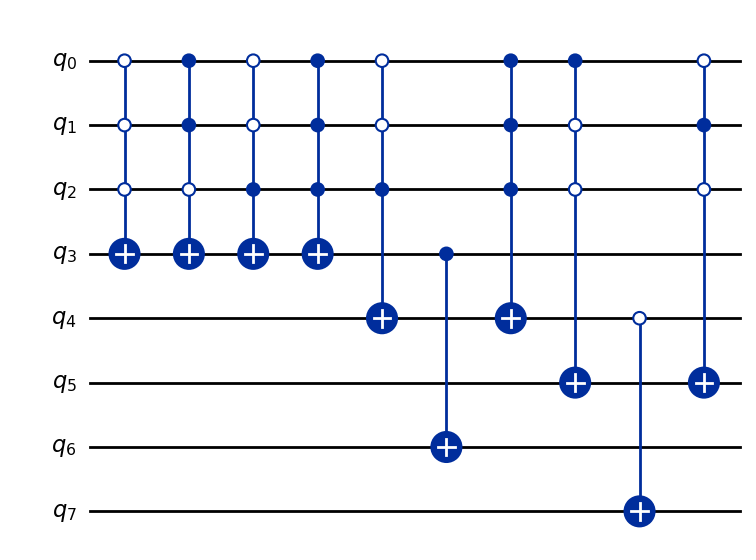

In [2]:
# We will hardcode the chosen F function with MCX Gates, according to the table above
def f_function(display_fig=False):
    '''
        f(x) is written onto the m last qubits
    '''
    f = QuantumCircuit(total_qubits)
    # First bit of f(x) is 1 if the first 3 bits are [000, 011, 100, 111]
    f.append(MCXGate(3, ctrl_state='000'), [0,1,2,3])
    f.append(MCXGate(3, ctrl_state='011'), [0,1,2,3])
    f.append(MCXGate(3, ctrl_state='100'), [0,1,2,3])
    f.append(MCXGate(3, ctrl_state='111'), [0,1,2,3])
    # Second bit of f(x) is 1 if the first 3 bits are [100, 111]
    f.append(MCXGate(3, ctrl_state='100'), [0,1,2,4])
    f.append(MCXGate(3, ctrl_state='111'), [0,1,2,4])
    # Third bit of f(x) is 1 if the first 3 bits are [001, 010]
    f.append(MCXGate(3, ctrl_state='001'), [0,1,2,5])
    f.append(MCXGate(3, ctrl_state='010'), [0,1,2,5])
    # Fourth bit of f(x) is 1 if the first bit of f(x) is 1
    f.append(MCXGate(1, ctrl_state='1'), [3,6])
    # Fifth bit of f(x) is 1 if the second bit of f(x) is 0
    f.append(MCXGate(1, ctrl_state='0'), [4,7])
    
    if display_fig:
        fig = f.draw("mpl")
        display(fig)
    return f

f = f_function(display_fig=True)

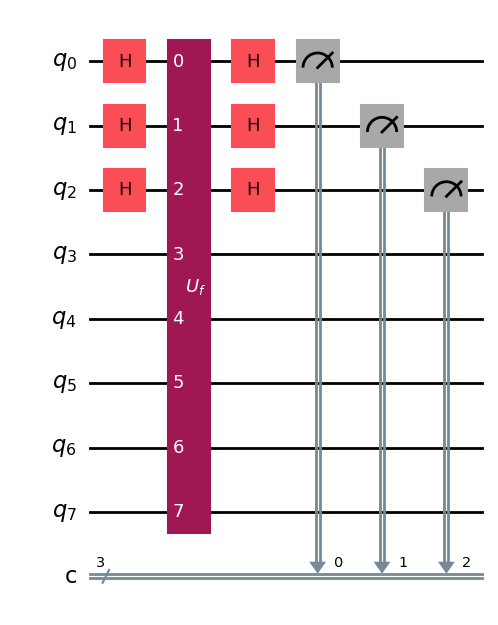

In [3]:
# We'll wrap the f function into a gate to simplify the circuit
blackbox = f_function().to_gate()
blackbox.label = "$U_f$"

# Simon's circuit
qc_simon = QuantumCircuit(total_qubits, n)
qc_simon.h(range(n))
qc_simon.compose(blackbox, inplace=True)
qc_simon.h(range(n))
qc_simon.measure(range(n), range(n))
qc_simon.draw("mpl")

### Simon's algorithm
___

In [4]:
# We use the run function provided in another IBM course
def run_circuit_and_get_counts(circuit, backend, shots=1000):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    data = result[0].data
    counts = data[list(data.keys())[0]].get_counts()
    return counts

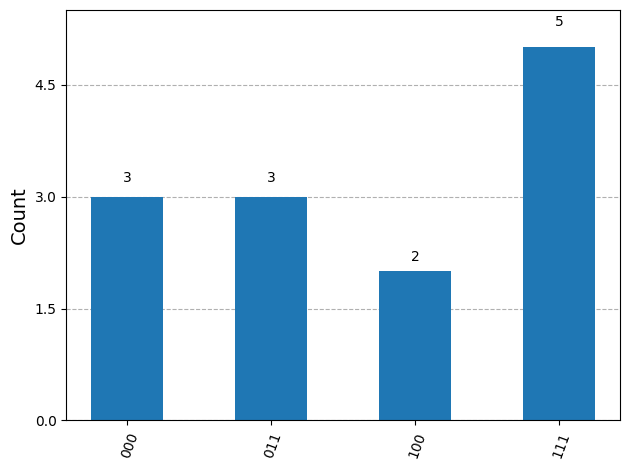

In [5]:
# First we need to run the circuit k times
r = 10
k = n+r # With r=10, we should be successful with probability>99.9%
backend = AerSimulator()
counts = run_circuit_and_get_counts(qc_simon, backend, shots=k)
plot_histogram(counts)

In [6]:
# Then, we make a matrix M out of the results
M = []
for y, frequency in counts.items():
    for i in range(frequency):
        M.append([int(s) for s in y])
M = np.array(M)
print(M)

[[1 1 1]
 [1 1 1]
 [1 1 1]
 [1 1 1]
 [1 1 1]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 1 1]
 [0 1 1]
 [0 1 1]
 [1 0 0]
 [1 0 0]]


In [7]:
# Convert to SymPy matrix to use its null space function
M_sym = Matrix(M)

# Compute null space
nullspace = M_sym.nullspace()

# Modulo 2
s = np.array(nullspace[0]) % 2

# Convert the result to a string
s = "".join([str(s) for s in s.flatten()])
print("s =", s)

s = 011


### Result
___
The right string s=011 was indeed found with only 13 shots.